# Anderson-Darling Test for Normality

The **Anderson-Darling test** is a goodness-of-fit test that weights the tails of the distribution more heavily than the Kolmogorov-Smirnov test, making it more sensitive to departures from normality in the tails. It is the recommended test for normality in most EDA applications.

| Property | Value |
|---|---|
| **H₀** | Data follows the specified distribution (usually Normal) |
| **H₁** | Data does not follow the distribution |
| **Test statistic** | A² = −n − (1/n)Σ(2i−1)[ln F(xᵢ) + ln(1−F(xₙ₊₁₋ᵢ))] |
| **Tail emphasis** | Weights tails more heavily than KS test |
| **Critical values** | Distribution-free tables; depend on sample size |
| **Power** | More powerful than KS for detecting tail departures |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

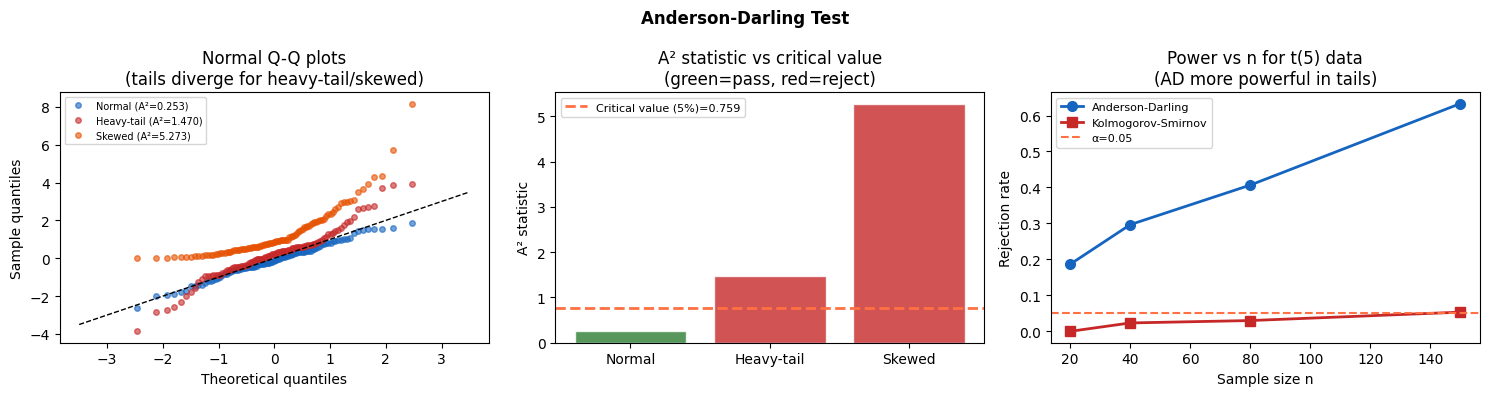

Normal      : A²=0.2534, crit(5%)=0.7590 → Fail to reject (normal)
Heavy-tail  : A²=1.4703, crit(5%)=0.7590 → Reject (non-normal)
Skewed      : A²=5.2726, crit(5%)=0.7590 → Reject (non-normal)


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Anderson-Darling Test', fontsize=12, fontweight='bold')

n = 100
datasets = {
    'Normal':     np.random.normal(0, 1, n),
    'Heavy-tail': stats.t.rvs(df=3, size=n),
    'Skewed':     stats.expon.rvs(size=n),
}

ad_results = {}
for name, data in datasets.items():
    result = stats.anderson(data, dist='norm')
    ad_results[name] = result

# Panel 1: Q-Q plots for all three
for i, (name, data) in enumerate(datasets.items()):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    color = ['#1565C0','#C62828','#E65100'][i]
    label = f'{name} (A²={ad_results[name].statistic:.3f})'
    axes[0].plot(osm, osr, 'o', color=color, ms=4, alpha=0.6, label=label)
axes[0].plot([-3.5, 3.5], [-3.5, 3.5], 'k--', lw=1)
axes[0].set_title('Normal Q-Q plots\n(tails diverge for heavy-tail/skewed)')
axes[0].set_xlabel('Theoretical quantiles'); axes[0].set_ylabel('Sample quantiles')
axes[0].legend(fontsize=7)

# Panel 2: A² statistic vs critical values
names = list(ad_results.keys())
a2_vals = [ad_results[n].statistic for n in names]
crit_5pct = ad_results[names[0]].critical_values[2]  # 5% significance level
x_pos = np.arange(len(names))
bar_colors = ['#2E7D32' if v < crit_5pct else '#C62828' for v in a2_vals]
axes[1].bar(x_pos, a2_vals, color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].axhline(crit_5pct, color='#FF7043', lw=2, ls='--', label=f'Critical value (5%)={crit_5pct:.3f}')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(names)
axes[1].set_title('A² statistic vs critical value\n(green=pass, red=reject)')
axes[1].set_ylabel('A² statistic'); axes[1].legend(fontsize=8)

# Panel 3: power comparison with KS test at various sample sizes
sample_sizes = [20, 40, 80, 150]
power_ad, power_ks = [], []
n_sims = 300
for ni in sample_sizes:
    reject_ad = reject_ks = 0
    for _ in range(n_sims):
        heavy = stats.t.rvs(df=5, size=ni)
        ad_r = stats.anderson(heavy, dist='norm')
        if ad_r.statistic > ad_r.critical_values[2]:
            reject_ad += 1
        ks_s, ks_p = stats.kstest(heavy, 'norm', args=(heavy.mean(), heavy.std()))
        if ks_p < 0.05:
            reject_ks += 1
    power_ad.append(reject_ad / n_sims)
    power_ks.append(reject_ks / n_sims)

axes[2].plot(sample_sizes, power_ad, 'o-', color='#1565C0', lw=2, ms=7, label='Anderson-Darling')
axes[2].plot(sample_sizes, power_ks, 's-', color='#C62828', lw=2, ms=7, label='Kolmogorov-Smirnov')
axes[2].axhline(0.05, color='#FF7043', lw=1.5, ls='--', label='α=0.05')
axes[2].set_title('Power vs n for t(5) data\n(AD more powerful in tails)')
axes[2].set_xlabel('Sample size n'); axes[2].set_ylabel('Rejection rate')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
for name, data in datasets.items():
    r = stats.anderson(data, dist='norm')
    sig = r.critical_values[2]
    decision = 'Reject (non-normal)' if r.statistic > sig else 'Fail to reject (normal)'
    print(f'{name:12s}: A²={r.statistic:.4f}, crit(5%)={sig:.4f} → {decision}')

## Key Takeaways

| | |
|---|---|
| **Tail weighting** | A² penalises tail departures more than KS — better for detecting t-distribution data |
| **vs Shapiro-Wilk** | Shapiro-Wilk is slightly more powerful for pure normality testing |
| **Modified A²** | For small samples, critical values must be adjusted (scipy does this) |
| **Distribution free** | Can test against Exponential, Weibull, Logistic too |
| **Critical values** | Vary by significance level: 15%, 10%, 5%, 2.5%, 1% |
| **Practical rule** | For EDA, combine A² with Q-Q plot — test plus visual confirmation |